All configuration and model checks passed.
[0.    0.025 0.05  0.075 0.1  ]


/home/koley/pySeis1DNN/modules/NNCompute.py:814: RuntimeWarning: invalid value encountered in sqrt
  qP = (2*np.pi*freqs)/(vR*vP[0])*np.sqrt(vP[0]**2 - vR**2)
/home/koley/pySeis1DNN/modules/NNCompute.py:815: RuntimeWarning: invalid value encountered in sqrt
  qS = (2*np.pi*freqs)/(vR*vS[0])*np.sqrt(vS[0]**2 - vR**2)


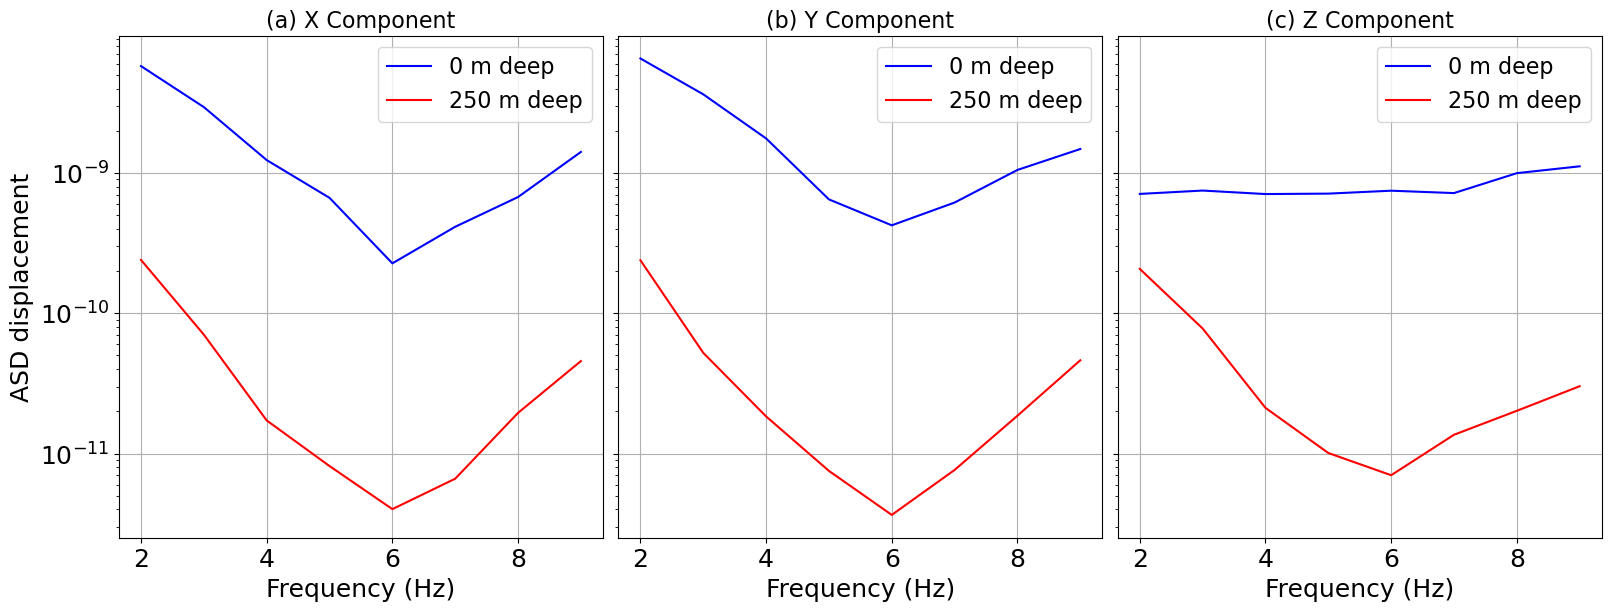

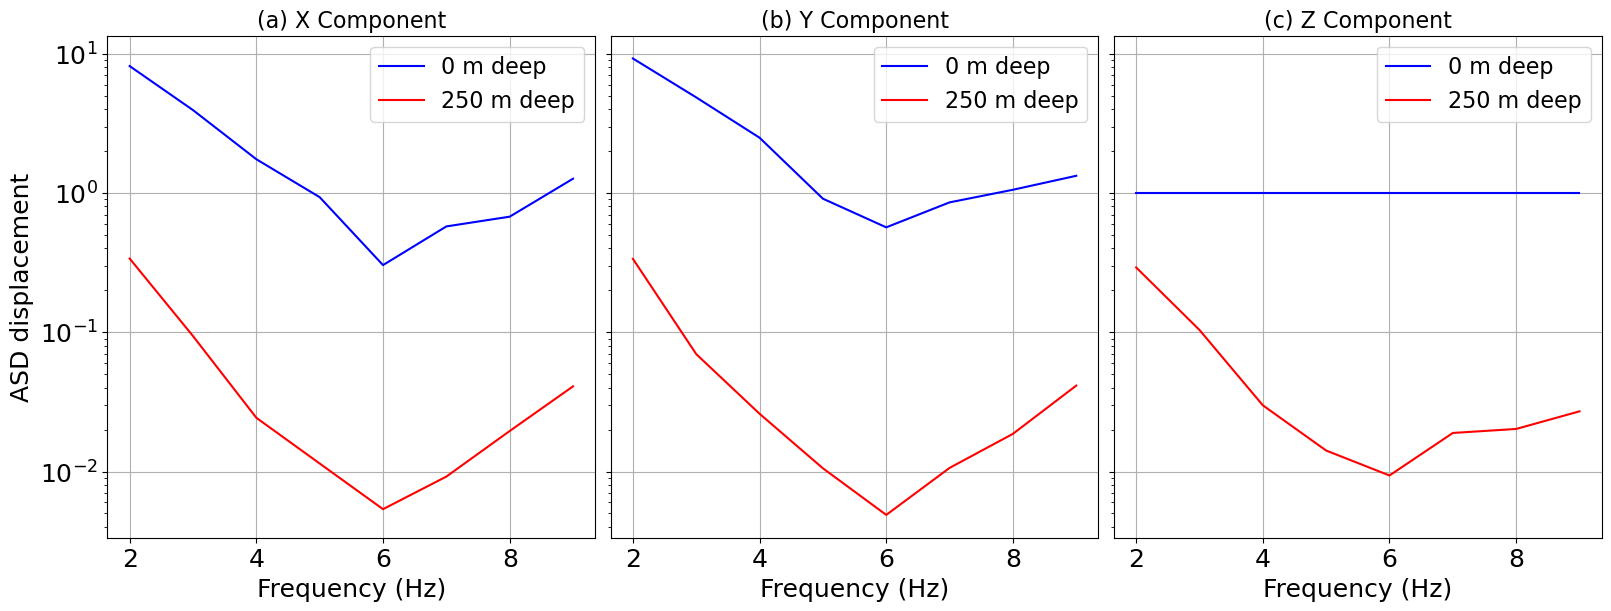

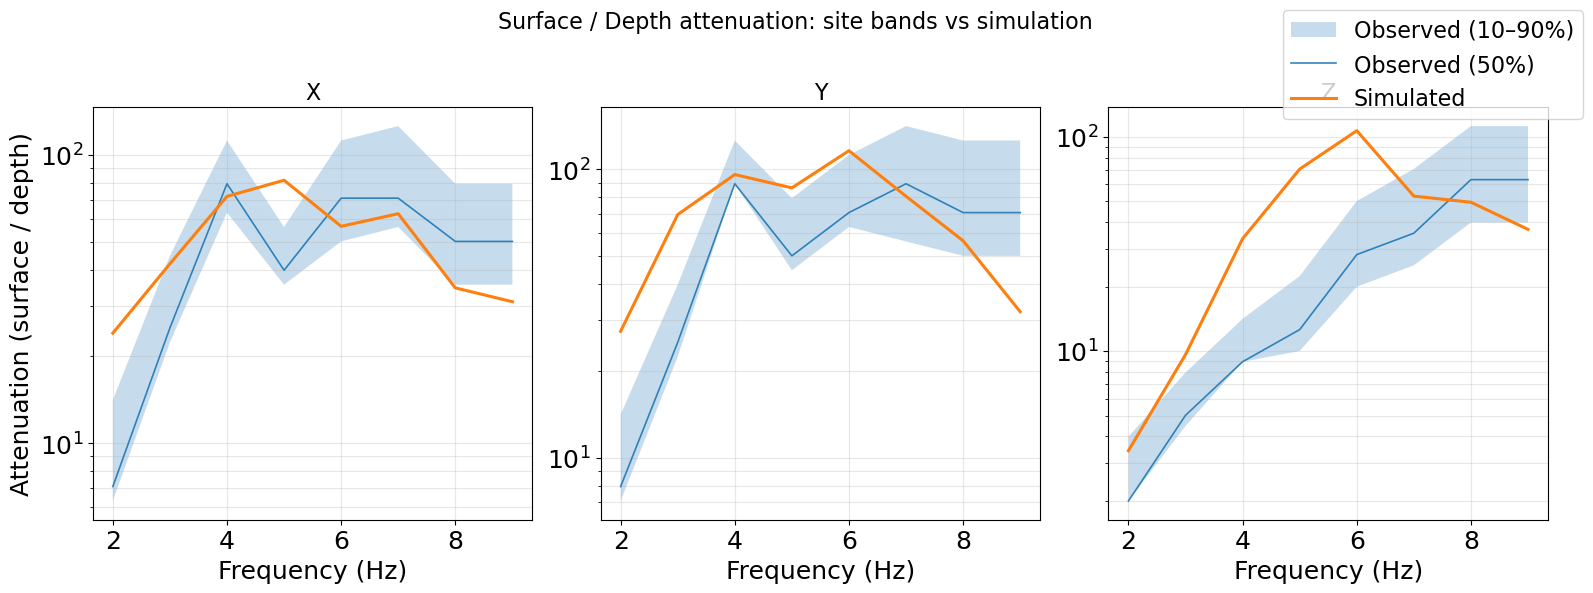

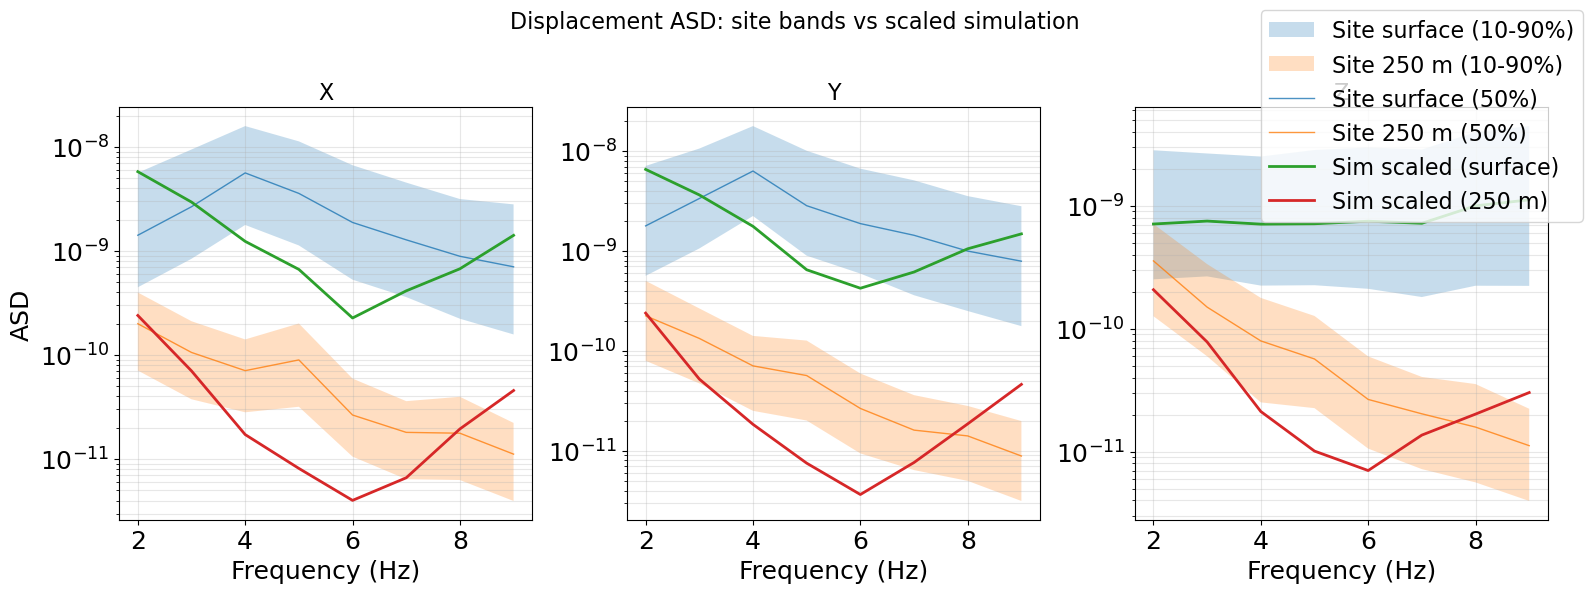

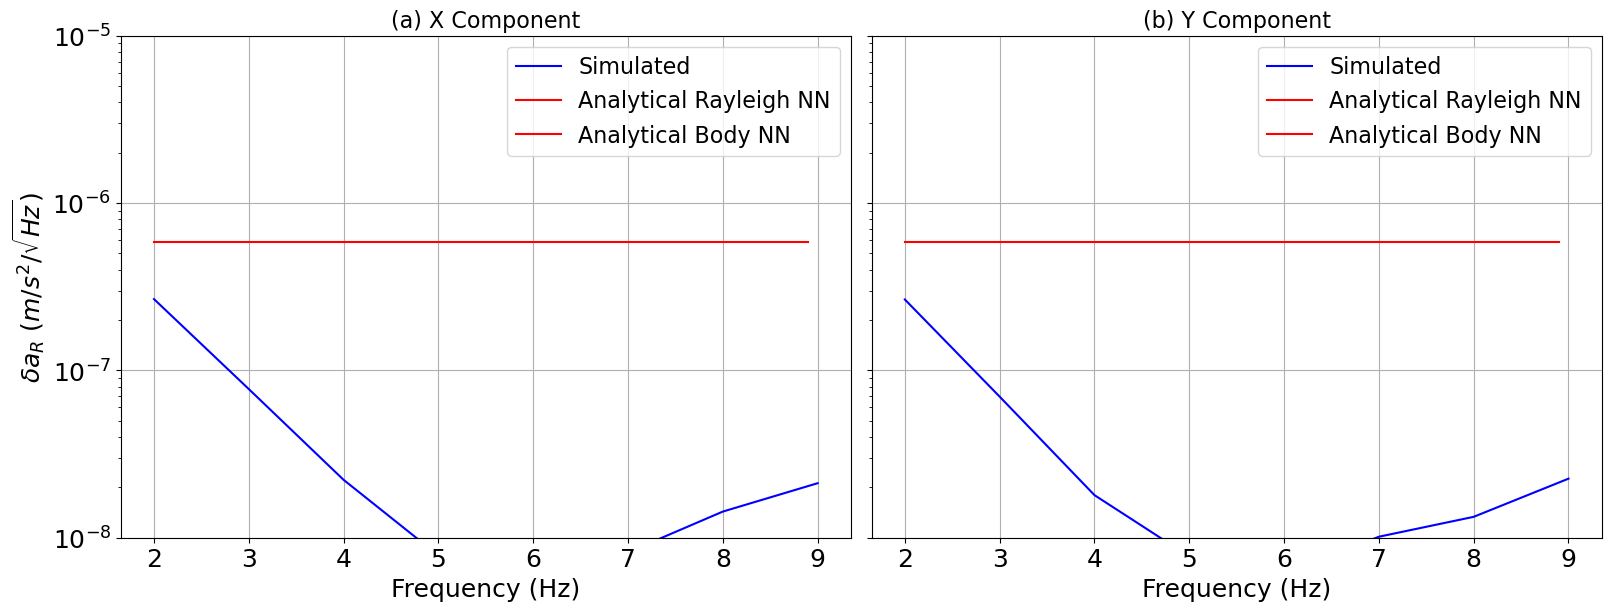

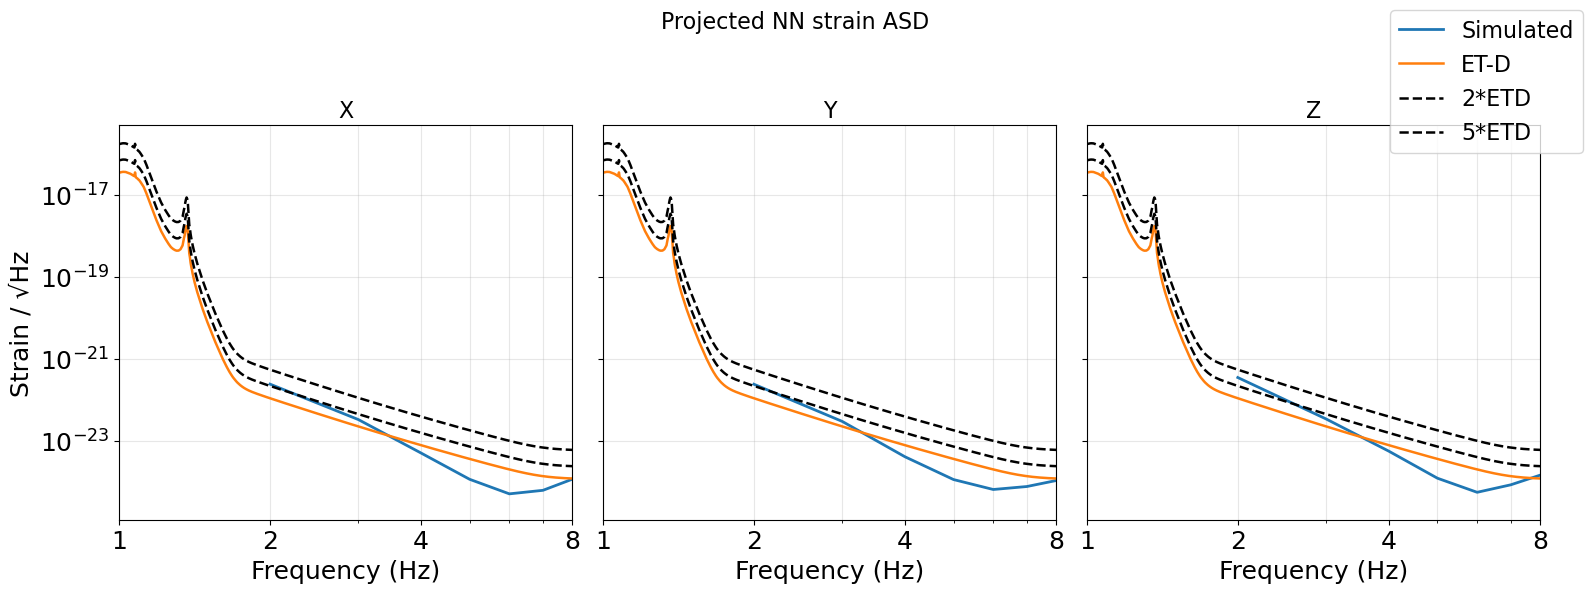

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.io import loadmat
from modules import configLoader
from modules import validateInputs
from modules import simDisp
from modules import NNCompute
from modules import plotUtils

def main():

    plotUtils.set_plot_style(labelsize=18, ticksize=18, legendsize=16)

    configFile="/home/koley/Results/FullRunConfig/configParseHomoNV.ini"
    figPath = "/home/koley/Results/FullHomoBigRing/Figures/FullHomoBigRingNN.pdf"
    config = configLoader.load_config(configFile)
    validateInputs.validateInputs(config)

    ifRay = config.ifRay

    ifBody = config.ifBody

    fMin = config.fMin; fMax = config.fMax; df = config.df;# units in Hz

    tMax = config.tMax; nSamp = config.nSamp

    outDispRea = config.outDispPathRea # like "/data/gravwav/koley/OutDispRea/"

    nRea = config.nRea # number of realizations
    #nRea = 10

    freqOut, idxFreq, df_native = simDisp.getFreqGrid(tMax, nSamp, fMin, fMax, df)
    nFreq = len(freqOut)

    # two depth points for scaling, displacement saved per realization
    zList = [0.0,config.cavityDepth]

    dispPointAllRea, attnAllRea, freqDisp = simDisp.assembleSurfDeepDispAllRea(outDispRea, zList, freqOut, nRea)
    scaledSimDisp, asdSurfX, asdSurfY, asdSurfZ, asdBHX, asdBHY, asdBHZ = scaleDisp(
        dispPointAllRea, freqOut, config, scaleComp='E', scaleDepth = 'depth', scaleToTrue=True)

    scaledSimDispFalse, asdSurfXF, asdSurfYF, asdSurfZF, asdBHXF, asdBHYF, asdBHZF = scaleDisp(
        dispPointAllRea, freqOut, config, scaleComp='E', scaleDepth = 'depth', scaleToTrue=False)
    
    # make plot
    figDisp, axDisp = plotUtils.plotPSDDeepSurfMulti(freqOut, scaledSimDisp[:,:,0], '0 m deep', 'b', fig=None, axs=None, 
                                         quantity="ASD displacement")
    figDisp, axDisp = plotUtils.plotPSDDeepSurfMulti(freqOut, scaledSimDisp[:,:,1], '250 m deep', 'r', fig=figDisp, axs=axDisp, 
                                         quantity="ASD displacement")
    
    figDispF, axDispF = plotUtils.plotPSDDeepSurfMulti(freqOut, scaledSimDispFalse[:,:,0], '0 m deep', 'b', fig=None, axs=None, 
                                         quantity="ASD displacement")
    figDispF, axDispF = plotUtils.plotPSDDeepSurfMulti(freqOut, scaledSimDispFalse[:,:,1], '250 m deep', 'r', fig=figDispF, axs=axDispF, 
                                         quantity="ASD displacement")
    
    attnSim, attnX, attnY, attnZ = getAttn(dispPointAllRea,freqOut,config)

    figAttn, axAttn = plotUtils.plotAttn(freqOut, attnSim, attnX, attnY, attnZ)
    
    figSh, axSh = plotUtils.plotScaledVsSiteASD(freqOut, scaledSimDisp, asdSurfX, asdSurfY, asdSurfZ,
                                                asdBHX, asdBHY, asdBHZ)
    
    #nnTotAllRea, fNN = NNCompute.assembleNNAllRea(outDispRea,freqOut, nRea)
    nnTotAllRea, nnVolAllRea, nnSurfAllRea, fNN = NNCompute.assembleNNAllRea(outDispRea,freqOut, nRea)

    scaledNN, *__ = scaleNN(
        nnTotAllRea, dispPointAllRea, freqOut, config, scaleComp="E", scaleDepth="depth",
        scaleToTrue=False)
    
    figNN, axNN = plotUtils.plotPSDDeepSurfMulti(fNN, scaledNN, 'Simulated', 'b', fig=None, axs=None, 
                                         quantity=r"$\delta a_R \ (m/s^2/\sqrt{Hz})$",subFigs=2)
    
    scaledNNToTrue, *__ = scaleNN(
        nnTotAllRea, dispPointAllRea, freqOut, config, scaleComp="E", scaleDepth="depth",
        scaleToTrue=True)
    nnProj, ETD = NNProjectToET(scaledNNToTrue, fNN, config)

    figSens, axSens = plotUtils.plotNNStrainET(fNN, nnProj, ETD, title="Projected NN strain ASD", xlim=(1, 8), xscale="log",
                   yscale="log", comp_labels=("X", "Y", "Z"), sim_label="Simulated", etd_label="ET-D",
                   legend_once=True, fig=None,axs=None)
    
    NNRay,freqNNRay = NNCompute.getAnalyticRayNN(config)
    NNBody, minNN, freqNNBody = NNCompute.getAnalyticBodyNN(config,p=1/3)

    axNN[0].plot(freqNNRay, NNRay,'r',label='Analytical Rayleigh NN')
    axNN[1].plot(freqNNRay, NNRay,'r',label='Analytical Rayleigh NN')
    #axNN[2].plot(freqNNRay, NNRay,'m',label='Analytical Rayleigh NN')

    axNN[0].plot(freqNNBody, NNBody,'r',label='Analytical Body NN')
    axNN[1].plot(freqNNBody, NNBody,'r',label='Analytical Body NN')
    #axNN[2].plot(freqNNBody, NNBody,'r',label='Analytical Body NN')

    #axNN[0].plot(freqNNBody, minNN,'g',label=r'$\frac{4\pi}{3} G \rho$')
    #axNN[1].plot(freqNNBody, minNN,'g',label=r'$\frac{4\pi}{3} G \rho$')
    #axNN[2].plot(freqNNBody, minNN,'g',label=r'$\frac{4\pi}{3} G \rho$')

    axNN[0].legend()
    axNN[1].legend()
    #axNN[2].legend()

    axNN[0].set_ylim(10**-8,10**-5)
    axNN[1].set_ylim(10**-8,10**-5)
    #axNN[2].set_ylim(5*10**-7,5*10**-6)

    #figNN.savefig(figPath, bbox_inches="tight",transparent=False,metadata={"Creator": "Python/Matplotlib"})

def NNProjectToET(scaledNN, freqOut, config, L = 10000, corrFact = 2):
    """
    function converts the NN acceleration ASD to strain ASD
    return the ET design sensitivity as well for comparing the projection
    scaledNN -> nFx3 array where the Newtonian acceleration have been scaled with site observed
    displacements
    freqOut -> array((nF,)) like
    config is used to get the path to the ET design curve
    L = 10000 is set to default as the interferometer arm length
    corrFactor = 2 as default for the contribution of 4 test-masses which is assumed to be
    independent and added in quadrature, so ASD the factor is sqrt(4) 
    """
    # first load the design sensitivity
    ETD = loadmat(os.path.join(config.etdPath,'ETD.mat'))
    ETDOut = ETD['ETD']

    nnProj = scaledNN/(L*4*(np.pi**2)*(freqOut[:,None]**2))*corrFact

    return nnProj, ETDOut
    
def scaleNN(nnAllRea, dispAllRea, freqOut, config, scaleComp="Z", scaleDepth="surface",
            scaleToTrue=False, site_percentile="p50", eps=1e-30):
    """
    Scale NN by reference displacement (to mimic unit displacement normalization),
    optionally scaling up to true site ASD.

    Parameters
    ----------
    nnAllRea : (nF,3) array (complex or real)
        NN output for one test mass, components [X,Y,Z] (or [E,N,Z]).
    dispAllRea : (nF,3,2) array (complex or real)
        Reference displacement at (0,0) or other reference point.
        components [X,Y,Z], depth index [surface(0), depth(1)].
    freqOut : (nF,) array
    config : config object with config.siteASDPath
    scaleComp : {"Z","E","N","all"}
        - "Z"/"E"/"N": scale ALL NN components by the chosen reference displacement component
        - "all": scale each NN component by its own corresponding displacement component
    scaleDepth : {"surface","depth"}
        Which displacement depth to use as reference.
    scaleToTrue : bool
        If True, multiply by site ASD (at chosen depth) for the reference component(s).
    site_percentile : {"p10","p50","p90"} or int
        Which column of the site ASD to use:
          p10->0, p50->1, p90->2
        You can also pass 0/1/2 directly.
    eps : float
        Small floor to prevent division blow-ups.

    Returns
    -------
    nnScaled : (nF,3) complex ndarray
        Scaled NN.
    asdSurfX/Y/Z, asdBHX/Y/Z : (nF,3) arrays
        Interpolated site ASDs (percentiles).
    """

    nnAllRea = np.asarray(nnAllRea)
    dispAllRea = np.asarray(dispAllRea)
    freqOut = np.asarray(freqOut)
    nF = freqOut.size

    if nnAllRea.shape != (nF, 3):
        raise ValueError(f"nnAllRea must be (nFreq,3), got {nnAllRea.shape}")
    if dispAllRea.shape != (nF, 3, 2):
        raise ValueError(f"dispAllRea must be (nFreq,3,2), got {dispAllRea.shape}")

    depth_idx = 0 if scaleDepth == "surface" else 1 if scaleDepth == "depth" else None
    if depth_idx is None:
        raise ValueError("scaleDepth must be 'surface' or 'depth'")

    # percentile column
    if isinstance(site_percentile, str):
        col_map = {"p10": 0, "p50": 1, "p90": 2}
        if site_percentile not in col_map:
            raise ValueError("site_percentile must be 'p10','p50','p90' or 0/1/2")
        pcol = col_map[site_percentile]
    else:
        pcol = int(site_percentile)
        if pcol not in (0, 1, 2):
            raise ValueError("site_percentile int must be 0,1,2")

    # --- load site ASDs ---
    siteASDSurf = loadmat(os.path.join(config.siteASDPath, "asdSurf.mat"))
    siteASDBH   = loadmat(os.path.join(config.siteASDPath, "asdBH.mat"))

    def interp3(mat, key):
        src = mat[key]         # columns: [f, p10, p50, p90]
        out = np.zeros((nF, 3))
        for i in range(3):
            out[:, i] = np.interp(freqOut, src[:, 0], src[:, i+1])
        return out

    asdSurfX = interp3(siteASDSurf, "asdSurfX")
    asdSurfY = interp3(siteASDSurf, "asdSurfY")
    asdSurfZ = interp3(siteASDSurf, "asdSurfZ")
    asdBHX   = interp3(siteASDBH,   "asdBHX")
    asdBHY   = interp3(siteASDBH,   "asdBHY")
    asdBHZ   = interp3(siteASDBH,   "asdBHZ")

    # choose site ASD array based on depth
    if scaleDepth == "surface":
        site_asd_vec = np.stack([asdSurfX[:, pcol], asdSurfY[:, pcol], asdSurfZ[:, pcol]], axis=1)  # (nF,3)
    else:
        site_asd_vec = np.stack([asdBHX[:, pcol],   asdBHY[:, pcol],   asdBHZ[:, pcol]], axis=1)

    # component mapping
    comp_idx = {"E": 0, "N": 1, "Z": 2, "X": 0, "Y": 1}

    nnScaled = nnAllRea.astype(np.complex128, copy=True)

    if scaleComp == "all":
        # scale each NN component by its matching displacement component at chosen depth
        denom = dispAllRea[:, :, depth_idx]                                # (nF,3)
        denom = np.where(np.abs(denom) < eps, eps, denom)
        nnScaled = nnScaled / denom                                         # broadcast (nF,3)/(nF,3)

        if scaleToTrue:
            nnScaled = nnScaled * site_asd_vec                              # (nF,3)

    else:
        if scaleComp not in comp_idx:
            raise ValueError("scaleComp must be 'Z','E','N','all' (or X/Y aliases)")
        refc = comp_idx[scaleComp]

        denom = dispAllRea[:, refc, depth_idx]                              # (nF,)
        denom = np.where(np.abs(denom) < eps, eps, denom)

        # scale all NN components by the same reference displacement component
        nnScaled = nnScaled / denom[:, None]

        if scaleToTrue:
            nnScaled = nnScaled * site_asd_vec[:, refc][:, None]            # multiply by site ASD of reference comp

    return nnScaled, asdSurfX, asdSurfY, asdSurfZ, asdBHX, asdBHY, asdBHZ

def getAttn(dispAllRea,freqOut, config):
    """
    function computes the attenuation from the simulated displacemments on surface and at depth
    loads the observed surface-underground attenuation at site
    """
    dispAllRea = np.asarray(dispAllRea)
    freqOut = np.asarray(freqOut)
    nF = freqOut.size
    attnX = np.zeros((nF,3)); attnY = np.zeros((nF,3)); attnZ = np.zeros((nF,3))
    attnSim = np.zeros((nF,3))

    terzAttn = loadmat(os.path.join(config.siteASDPath,'attnModel.mat'))
    for i in range(0,3):
        attnX[:,i] = np.interp(freqOut,terzAttn['attnE'][:,0],terzAttn['attnE'][:,i+1])
        attnY[:,i] = np.interp(freqOut,terzAttn['attnN'][:,0],terzAttn['attnN'][:,i+1])
        attnZ[:,i] = np.interp(freqOut,terzAttn['attnZ'][:,0],terzAttn['attnZ'][:,i+1])

    attnSim[:,0] = dispAllRea[:,0,0]/dispAllRea[:,0,1]
    attnSim[:,1] = dispAllRea[:,1,0]/dispAllRea[:,1,1]
    attnSim[:,2] = dispAllRea[:,2,0]/dispAllRea[:,2,1]

    return attnSim, attnX, attnY, attnZ

def scaleDisp(dispAllRea, freqOut, config, scaleComp="Z", scaleDepth="surface",
              scaleToTrue=False, eps=1e-30):
    """
    scales the simulated displacement to match the site asds
    dispAllRea -> array like, nFreq x 3 x 2
    the second dimension matches the three components in order X, Y, Z 
    the third dimension corresponds to the two depths -> (0,250)m
    scaleComp -> string: can be 'Z','N', 'E', or all
    1) in case 'Z' all simulated displacements are scaled such that asdZ=1
    this is physically the correct way, only one component must be normalized
    the remaining components must align is the model and the modeling is correct
    2) in case 'all', all respective components are scaled to 1: physically not
    the correct way
    scaleDepth -> string, can be 'surface' or depth: accordingly the surface or the depth
    is scaled to 1
    config.siteASDPath is used to load the observed sire ASDs
    scaleToTrue -> boolean, if True, the sites ASDs are used to scale teh simulated displacements

    returns: dispOut -> array like of size nFreq x 3 x 2
    dispOut is scalled to site displacement

    Returns scaledSimDisp plus interpolated ASDs.
    """

    dispAllRea = np.asarray(dispAllRea)
    freqOut = np.asarray(freqOut)
    nF = freqOut.size

    if dispAllRea.shape != (nF, 3, 2):
        raise ValueError(f"dispAllRea must be (nFreq,3,2), got {dispAllRea.shape}")

    depth_idx = 0 if scaleDepth == "surface" else 1 if scaleDepth == "depth" else None
    if depth_idx is None:
        raise ValueError("scaleDepth must be 'surface' or 'depth'")

    # --- load site ASDs ---
    siteASDSurf = loadmat(os.path.join(config.siteASDPath, "asdSurf.mat"))
    siteASDBH   = loadmat(os.path.join(config.siteASDPath, "asdBH.mat"))

    # helper: interpolate [freq, col1, col2, col3] -> (nF,3)
    def interp3(mat, key):
        src = mat[key]
        out = np.zeros((nF, 3))
        for i in range(3):
            out[:, i] = np.interp(freqOut, src[:, 0], src[:, i+1])
        return out

    asdSurfX = interp3(siteASDSurf, "asdSurfX")
    asdSurfY = interp3(siteASDSurf, "asdSurfY")
    asdSurfZ = interp3(siteASDSurf, "asdSurfZ")
    asdBHX   = interp3(siteASDBH,   "asdBHX")
    asdBHY   = interp3(siteASDBH,   "asdBHY")
    asdBHZ   = interp3(siteASDBH,   "asdBHZ")

    # choose which site ASD to apply if scaleToTrue
    # NOTE: This assumes that column 2 is the ASD you want (e.g.50th percentile).
    if scaleDepth == "surface":
        site_ref = {"E": asdSurfX[:, 1], "N": asdSurfY[:, 1], "Z": asdSurfZ[:, 1]}
    else:
        site_ref = {"E": asdBHX[:, 1],   "N": asdBHY[:, 1],   "Z": asdBHZ[:, 1]}

    # map component names to indices
    comp_idx = {"E": 0, "N": 1, "Z": 2, "X": 0, "Y": 1}

    scaled = np.empty_like(dispAllRea, dtype=np.complex128)

    if scaleComp == "all":
        # per-component scaling: each component normalized by itself at chosen depth
        denom = dispAllRea[:, :, depth_idx]                    # (nF,3)
        denom = np.where(np.abs(denom) < eps, eps, denom)      # guard
        scale = 1.0 / denom                                    # (nF,3)
        scaled = dispAllRea * scale[:, :, None]                # broadcast to (nF,3,2)

        if scaleToTrue:
            # apply component-wise site ASD at reference depth
            if scaleDepth == "surface":
                site = np.stack([asdSurfX[:, 1], asdSurfY[:, 1], asdSurfZ[:, 1]], axis=1)  # (nF,3)
            else:
                site = np.stack([asdBHX[:, 1], asdBHY[:, 1], asdBHZ[:, 1]], axis=1)
            scaled *= site[:, :, None]

    else:
        if scaleComp not in comp_idx:
            raise ValueError("scaleComp must be 'Z','E','N','all' (or X/Y aliases)")

        refc = comp_idx[scaleComp]
        denom = dispAllRea[:, refc, depth_idx]                 # (nF,)
        denom = np.where(np.abs(denom) < eps, eps, denom)
        scale = 1.0 / denom                                    # (nF,)

        scaled = dispAllRea * scale[:, None, None]             # (nF,3,2)

        if scaleToTrue:
            scaled *= site_ref[scaleComp][:, None, None]       # apply chosen reference ASD

    return scaled, asdSurfX, asdSurfY, asdSurfZ, asdBHX, asdBHY, asdBHZ

if __name__ == "__main__":
    main()